<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Engineering**

В этом курсе вы узнаете об одном из важнейших шагов на пути к созданию отличной модели машинного обучения: проектировании признаков. Вы научитесь:

*   определять, какие признаки являются наиболее важными, используя взаимную информацию;
*   создавать новые признаки в нескольких реальных предметных областях;
кодировать категориальные значения с высокой кардинальностью с помощью целевого кодирования;
*   создавать признаки сегментации с помощью кластеризации k-средних;
*   разлагать вариативность набора данных на признаки с помощью анализа главных компонентов.

Практические упражнения завершатся созданием полного блокнота, в котором все эти методы будут применены для участия в конкурсе House Prices Getting Started. После завершения курса у вас будет несколько идей, которые вы сможете использовать для дальнейшего улучшения своих результатов.

# **Цель разработки функциональных возможностей**
Цель инженерии признаков — просто сделать ваши данные более подходящими для решения поставленной задачи.
Рассмотрим показатели «ощущаемой температуры», такие как индекс жары и ветровое охлаждение. Эти величины пытаются измерить температуру, воспринимаемую человеком, на основе температуры воздуха, влажности и скорости ветра — параметров, которые мы можем измерить напрямую. Можно рассматривать ощущаемую температуру как результат своего рода инженерии признаков, попытку сделать наблюдаемые данные более релевантными тому, что нас действительно волнует: как на самом деле ощущается температура на улице!
Вы можете использовать инженерию признаков для:
*   улучшения прогностической эффективности модели;
*   снижения вычислительных или информационных потребностей;
*   улучшения интерпретируемости результатов.

# **Основной принцип инженерии признаков**

Чтобы признак был полезен, он должен иметь связь с целевым значением, которую ваша модель способна изучить. Линейные модели, например, способны изучать только линейные зависимости. Поэтому при использовании линейной модели ваша цель — преобразовать признаки, чтобы сделать их связь с целевым значением линейной.

Ключевая идея здесь заключается в том, что преобразование, которое вы применяете к признаку, по сути, становится частью самой модели. Допустим, вы пытаетесь предсказать цену квадратных участков земли на основе длины одной стороны. Подгонка линейной модели непосредственно к длине дает плохие результаты: связь не является линейной.
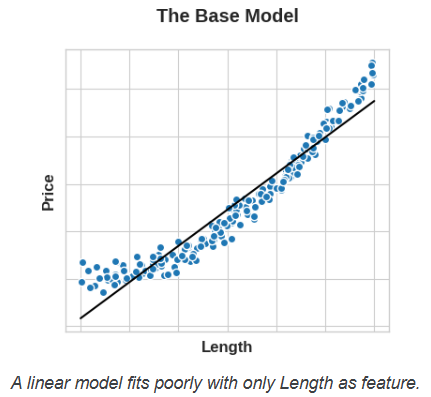

Однако, если мы возведем в квадрат функцию «Длина», чтобы получить «Площадь», мы создадим линейную зависимость. Добавление «Площади» к набору функций означает, что эта линейная модель теперь может аппроксимировать параболу. Другими словами, возведение функции в квадрат дает линейной модели возможность аппроксимировать функции, возведенные в квадрат.

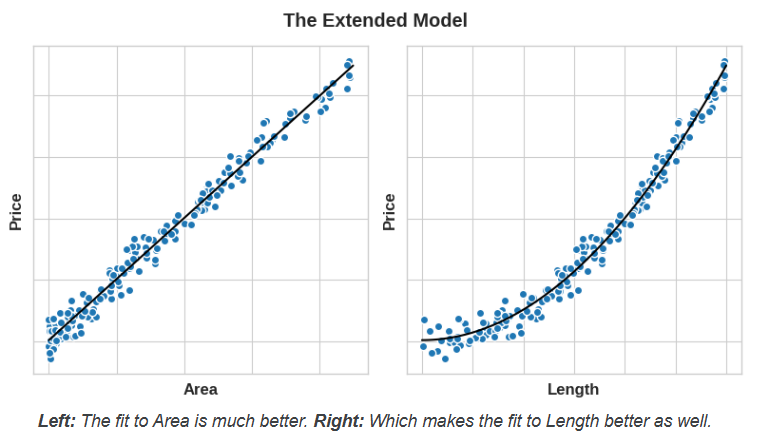

Это должно показать вам, почему время, затраченное на разработку признаков, может быть настолько эффективным. Какие бы взаимосвязи ваша модель не могла изучить самостоятельно, вы можете восстановить их с помощью преобразований. При разработке набора признаков подумайте о том, какую информацию ваша модель могла бы использовать для достижения наилучших результатов.

# **Пример — Состав бетона**

Чтобы проиллюстрировать эти идеи, мы увидим, как добавление нескольких синтетических признаков к набору данных может улучшить прогностическую эффективность модели случайного леса.

Набор данных «Бетон» https://www.kaggle.com/sinamhd9/concrete-comprehensive-strength содержит различные составы бетона и прочность на сжатие полученного продукта, которая является мерой того, какую нагрузку может выдержать данный вид бетона. Задача для этого набора данных — предсказать прочность бетона на сжатие, исходя из его состава.

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

df = pd.read_excel('/content/Concrete_Data.xls')
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


Здесь вы можете увидеть различные ингредиенты, входящие в состав каждого вида бетона. Через мгновение мы увидим, как добавление некоторых дополнительных синтетических признаков, полученных из этих ингредиентов, может помочь модели изучить важные взаимосвязи между ними.

Сначала мы установим базовый уровень, обучив модель на неаугментированном наборе данных. Это поможет нам определить, действительно ли наши новые признаки полезны.

Установление таких базовых уровней — хорошая практика на начальном этапе процесса проектирования признаков. Базовая оценка может помочь вам решить, стоит ли сохранять ваши новые признаки или следует отбросить их и, возможно, попробовать что-то другое.

In [3]:
X = df.copy()
y = X.pop('CompressiveStrength')

baseline = RandomForestRegressor(criterion='absolute_error', random_state=0)
baseline_score = cross_val_score(
    baseline, X, y, cv=5, scoring='neg_mean_absolute_error'
)
baseline_score = -1 * baseline_score.mean()

print(f'MAE Baseline Score: {baseline_score:.4}')

MAE Baseline Score: 8.397


Если вы когда-либо готовили дома, вы, вероятно, знаете, что соотношение ингредиентов в рецепте обычно лучше предсказывает конечный результат, чем их абсолютное количество. Таким образом, можно предположить, что соотношения указанных выше характеристик будут хорошим предиктором прочности на сжатие.

Ячейка ниже добавляет в набор данных три новых характеристики соотношения.

In [6]:
X['FCRatio'] = X['FineAggregate'] / X['CoarseAggregate']
X['AggCmtRatio'] = (X['CoarseAggregate'] + X['FineAggregate']) / X['Cement']
X['WtrCmtRatio'] = X['Water'] / X['Cement']

model = RandomForestRegressor(criterion="absolute_error", random_state=0)
score = cross_val_score(
    model, X, y, cv=5, scoring="neg_mean_absolute_error"
)
score = -1 * score.mean()

print(f"MAE Score with Ratio Features: {score:.4}")

MAE Score with Ratio Features: 8.011


И действительно, производительность улучшилась! Это свидетельствует о том, что новые характеристики соотношения выявили для модели важную информацию, которую она раньше не обнаруживала.